# Market Field reproducibility companion

## TL;DR

This notebook rebuilds and inspects the evidence reported in the ICLR-formatted
working paper. The tests cover causal-prefix invariance, deterministic state
learning, controlled representation behavior, a matched five-coordinate
single-horizon baseline, downstream entropy sensitivity, descriptive
calibration diagnostics, and local snapshot cost. The cheap baseline is more
readily partitioned than Market Field under the shared gate, so the notebook
does not support a superior-unsupervised-representation claim. It does not test
return predictability, option profitability, or a physical theory of markets.

## Context and methods

The notebook calls the repository's production Market Field functions through
the paper asset script. The default rerun is offline and requires the frozen
cache produced by a prior refresh. Provider retrieval, canonical row hashes,
sample dates, and adjustment mode are recorded in validation_summary.json.

The daily study covers SPY, QQQ, IWM, TLT, GLD, USO, VNQ, and BTC-USD from
2018-01-01 through the paper as-of date 2026-07-21. Chronological
fit/calibration/evaluation segmentation is performed by production code.

The baseline changes the representation while retaining the production
chronology, deterministic clustering, support threshold, silhouette gate, and
held-out calibration-distance test. A separate SPY ablation recomputes the
complete dictionary at entropy windows 8, 12, 24, 48, and 96.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

PAPER_ROOT = Path.cwd().resolve()
assert (PAPER_ROOT / "scripts" / "generate_assets.py").exists(), (
    "Run this notebook with docs/papers/market-field as the working directory."
)
print("Paper package:", PAPER_ROOT.name)
print("Python:", sys.version.split()[0])

Paper package: market-field
Python: 3.13.14


## Data and artifact rebuild

In [2]:
completed = subprocess.run(
    [sys.executable, str(PAPER_ROOT / "scripts" / "generate_assets.py"), "--offline"],
    cwd=PAPER_ROOT,
    check=True,
    capture_output=True,
    text=True,
)
print(completed.stdout)

{
  "status": "ok",
  "paper_as_of": "2026-07-21",
  "assets": 8,
  "derived_rows": 7270,
  "prefix_comparisons": 6688,
  "figures": [
    "calibration_rates.pdf",
    "representation_sensitivity.pdf",
    "spy_field_phase.pdf",
    "synthetic_diagnostics.pdf",
    "system_overview.pdf"
  ],
  "tables": [
    "asset_summary.tex",
    "representation_comparison.tex",
    "validation_summary.tex"
  ],
  "primary_run_receipt": "primary_run_receipt.json",
  "provenance_core_sha256": "0632dd4f1c1ee4168221b365d0f275a02ecb4daa19ecff2ceebe0dcca3d497b9"
}



In [3]:
summary = json.loads(
    (PAPER_ROOT / "results" / "validation_summary.json").read_text(encoding="utf-8")
)
assets = pd.read_csv(PAPER_ROOT / "results" / "asset_summary.csv")
representations = pd.read_csv(
    PAPER_ROOT / "results" / "representation_baseline.csv"
)
window_stability = pd.read_csv(
    PAPER_ROOT / "results" / "representation_window_stability.csv"
)
entropy_sensitivity = pd.read_csv(
    PAPER_ROOT / "results" / "entropy_dictionary_sensitivity.csv"
)
bibliography_audit = pd.read_csv(
    PAPER_ROOT / "results" / "bibliography_audit.csv"
)
manifest = pd.DataFrame(summary["market_data"])
manifest[
    ["symbol", "rows", "first_observation", "last_observation",
     "adjustment", "canonical_ohlcv_sha256"]
]

,symbol,rows,first_observation,last_observation,adjustment,canonical_ohlcv_sha256
0,SPY,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,ea77800c08663cb150f1b04125d897e62061d5d0a5e6e6...
1,QQQ,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,00ce949bf1318fadab102ae859cb9ac5f73454ad78f8fb...
2,IWM,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,60edd0ee5b7d9d9dad098d831128638252f0bdda2665c9...
3,TLT,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,0089ee8a52a195ee1ca36467d31ab495df16ea608b450e...
4,GLD,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,f004bce65315d319e6724423f4da6356f6dbc8e462fcea...
5,USO,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,de1a67bbfedec724465db2c5f927e9342001843a698a07...
6,VNQ,2148,2018-01-02T05:00:00+00:00,2026-07-21T04:00:00+00:00,Yahoo auto_adjust=True,519c362eb2510bfd30134a1282e2a1af20bf18a22d688b...
7,BTC-USD,3124,2018-01-01T00:00:00+00:00,2026-07-21T00:00:00+00:00,Yahoo auto_adjust=True,07faa51bb53f39f7e8c78064fc0d9ea2200cb869553577...


## Results

The following assertions are executable claim guards. They intentionally stop
short of any predictive or economic-performance assertion.

In [4]:
validation = summary["validation"]
synthetic = summary["synthetic"]
benchmark = summary["option_snapshot_benchmark"]
representation_summary = summary["representation_comparison"]

assert validation["prefix_invariance"]["nonzero_differences"] == 0
assert validation["prefix_invariance"]["serialized_value_comparisons"] == 6688
assert validation["determinism"]["exact_lexicon_matches"] == 8
assert synthetic["horizon_delay_spearman_rho"] == 1.0
assert benchmark["rank_influence"] == 0.0
assert benchmark["automated_execution_enabled"] is False
assert representation_summary["market_field_nontrivial_codebooks"] == 2
assert representation_summary["baseline_nontrivial_codebooks"] == 8
assert representations.groupby("symbol")["requested_warmup_bars"].nunique().eq(1).all()
assert entropy_sensitivity["forms"].eq(2).all()
assert entropy_sensitivity.loc[
    entropy_sensitivity["entropy_window_patterns"] != 24,
    "assignment_ari_vs_window24",
].min() > 0.85
assert bibliography_audit["status"].isin(
    ["verified", "verified_reachable", "metadata_discrepancy"]
).all()

pd.DataFrame(
    [
        {
            "diagnostic": "Prefix invariance",
            "result": (
                f'{validation["prefix_invariance"]["serialized_value_comparisons"]:,} '
                "comparisons; zero mismatches"
            ),
        },
        {
            "diagnostic": "Dictionary determinism",
            "result": (
                f'{validation["determinism"]["exact_lexicon_matches"]}/'
                f'{validation["determinism"]["symbols"]} exact reruns'
            ),
        },
        {
            "diagnostic": "Synthetic horizon delay",
            "result": f'Spearman rho = {synthetic["horizon_delay_spearman_rho"]:.3f}',
        },
        {
            "diagnostic": "Supported calibration-distance tails",
            "result": (
                f'{100 * validation["distance_tail"]["pooled_outside_range_rate"]:.2f}% '
                "in the upper state-conditional calibration-distance tail"
            ),
        },
        {
            "diagnostic": "Matched representation baseline",
            "result": (
                f'{representation_summary["market_field_nontrivial_codebooks"]}/8 '
                "Market Field vs "
                f'{representation_summary["baseline_nontrivial_codebooks"]}/8 '
                "baseline multi-Form codebooks"
            ),
        },
        {
            "diagnostic": "SPY entropy assignment sensitivity",
            "result": (
                f'ARI {entropy_sensitivity.loc[entropy_sensitivity["entropy_window_patterns"] != 24, "assignment_ari_vs_window24"].min():.3f}'
                "–"
                f'{entropy_sensitivity.loc[entropy_sensitivity["entropy_window_patterns"] != 24, "assignment_ari_vs_window24"].max():.3f}'
            ),
        },
        {
            "diagnostic": "Compact snapshot",
            "result": (
                f'{benchmark["median_ms"]:.1f} ms median; '
                f'{benchmark["median_payload_bytes"]:,} bytes'
            ),
        },
    ]
)

,diagnostic,result
0,Prefix invariance,"6,688 comparisons; zero mismatches"
1,Dictionary determinism,8/8 exact reruns
2,Synthetic horizon delay,Spearman rho = 1.000
3,Supported calibration-distance tails,5.46% in the upper state-conditional calibrati...
4,Matched representation baseline,2/8 Market Field vs 8/8 baseline multi-Form co...
5,SPY entropy assignment sensitivity,ARI 0.878–0.908
6,Compact snapshot,"107.7 ms median; 4,395 bytes"


In [5]:
asset_display = assets[
    [
        "symbol", "bars", "forms", "fit_silhouette",
        "tail_supported_bars", "outside_range_rate",
        "transitions_per_100_bars",
    ]
].copy()
asset_display = asset_display.rename(
    columns={"outside_range_rate": "upper_calibration_distance_tail_rate"}
)
asset_display["fit_silhouette"] = asset_display["fit_silhouette"].map("{:.3f}".format)
asset_display["upper_calibration_distance_tail_rate"] = asset_display[
    "upper_calibration_distance_tail_rate"
].map("{:.2%}".format)
asset_display["transitions_per_100_bars"] = asset_display[
    "transitions_per_100_bars"
].map("{:.2f}".format)
asset_display

,symbol,bars,forms,fit_silhouette,tail_supported_bars,upper_calibration_distance_tail_rate,transitions_per_100_bars
0,SPY,2148,2,0.320,860,10.58%,2.56
1,QQQ,2148,1,0.000,860,4.42%,0.00
2,IWM,2148,1,0.000,860,6.63%,0.00
3,TLT,2148,1,0.000,860,3.26%,0.00
4,GLD,2148,1,0.000,860,6.63%,0.00
5,USO,2148,3,0.315,827,6.77%,1.98
6,VNQ,2148,1,0.000,860,1.51%,0.00
7,BTC-USD,3124,1,0.000,1250,4.40%,0.00


### Matched baseline and downstream entropy sensitivity

In [6]:
representation_display = representations[
    [
        "symbol", "representation", "requested_warmup_bars", "forms", "features",
        "fit_silhouette", "tail_rate", "transitions_per_100_bars",
    ]
].copy()
representation_display["fit_silhouette"] = representation_display[
    "fit_silhouette"
].map("{:.3f}".format)
representation_display["tail_rate"] = representation_display[
    "tail_rate"
].map("{:.2%}".format)
representation_display

,symbol,representation,requested_warmup_bars,forms,features,fit_silhouette,tail_rate,transitions_per_100_bars
0,SPY,market_field_v1,96,2,15,0.320,10.58%,2.561118
1,SPY,single_horizon_baseline,96,2,5,0.574,2.79%,6.053551
2,QQQ,market_field_v1,96,1,15,0.000,4.42%,0.000000
3,QQQ,single_horizon_baseline,96,2,5,0.549,0.12%,6.169965
4,IWM,market_field_v1,96,1,15,0.000,6.63%,0.000000
5,IWM,single_horizon_baseline,96,2,5,0.447,5.93%,3.958091
6,TLT,market_field_v1,96,1,15,0.000,3.26%,0.000000
7,TLT,single_horizon_baseline,96,3,5,0.327,12.79%,10.011641
8,GLD,market_field_v1,96,1,15,0.000,6.63%,0.000000
9,GLD,single_horizon_baseline,96,2,5,0.384,11.98%,4.423749


In [7]:
display(window_stability)
entropy_display = entropy_sensitivity.copy()
entropy_display["information_correlation_vs_window24"] = entropy_display[
    "information_correlation_vs_window24"
].map("{:.3f}".format)
entropy_display["assignment_ari_vs_window24"] = entropy_display[
    "assignment_ari_vs_window24"
].map("{:.3f}".format)
entropy_display["tail_rate"] = entropy_display["tail_rate"].map("{:.2%}".format)
entropy_display

,representation,prefix_fraction,prefix_bars,prefix_forms,full_forms,overlap_bars,adjusted_rand_index
0,market_field_v1,0.70,1504,2,2,216,0.841973
1,single_horizon_baseline,0.70,1504,2,2,216,0.803470
2,market_field_v1,0.85,1826,2,2,538,0.750574
3,single_horizon_baseline,0.85,1826,2,2,538,0.924911


,symbol,entropy_window_patterns,information_correlation_vs_window24,forms,fit_silhouette,assignment_ari_vs_window24,assignment_overlap_bars,tail_supported_bars,tail_rate,transitions_per_100_bars
0,SPY,8,0.492,2,0.327455,0.903,860,860,14.07%,3.026775
1,SPY,12,0.661,2,0.328615,0.908,860,860,12.33%,3.259604
2,SPY,24,1.000,2,0.320191,1.000,860,860,10.58%,2.561118
3,SPY,48,0.717,2,0.321715,0.878,860,860,16.74%,2.793946
4,SPY,96,0.511,2,0.328019,0.883,860,860,12.09%,2.793946


The baseline's stronger fit separation is a negative result for representation
superiority. Entropy-window changes preserve the coarse two-Form SPY partition
reasonably well on this long sample, but the calibration-tail rate and
transition frequency remain parameter-sensitive.

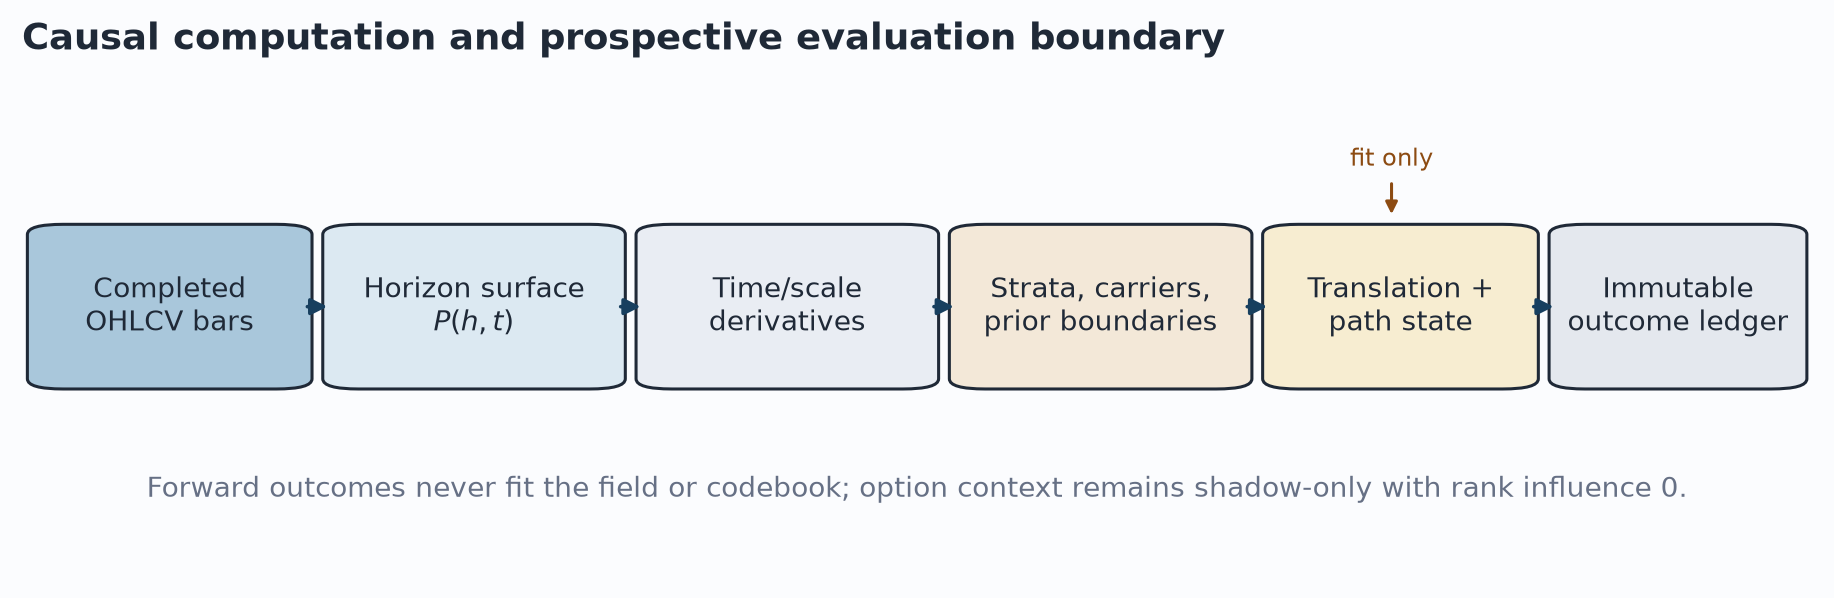

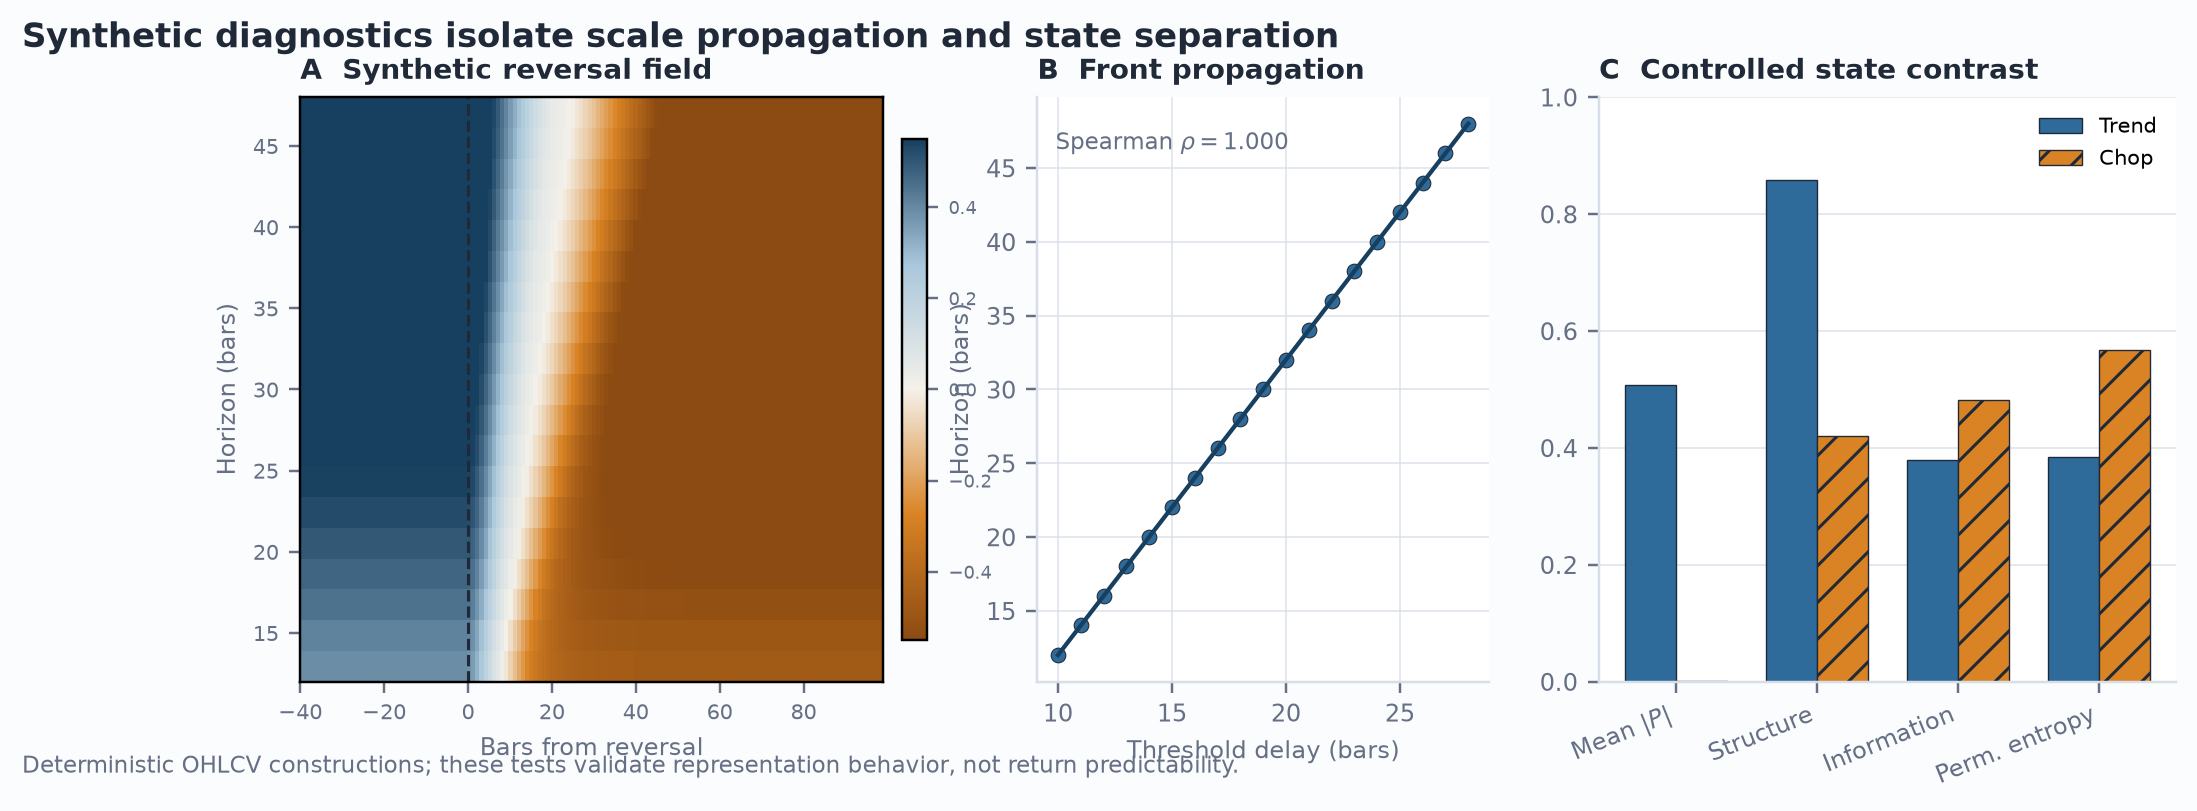

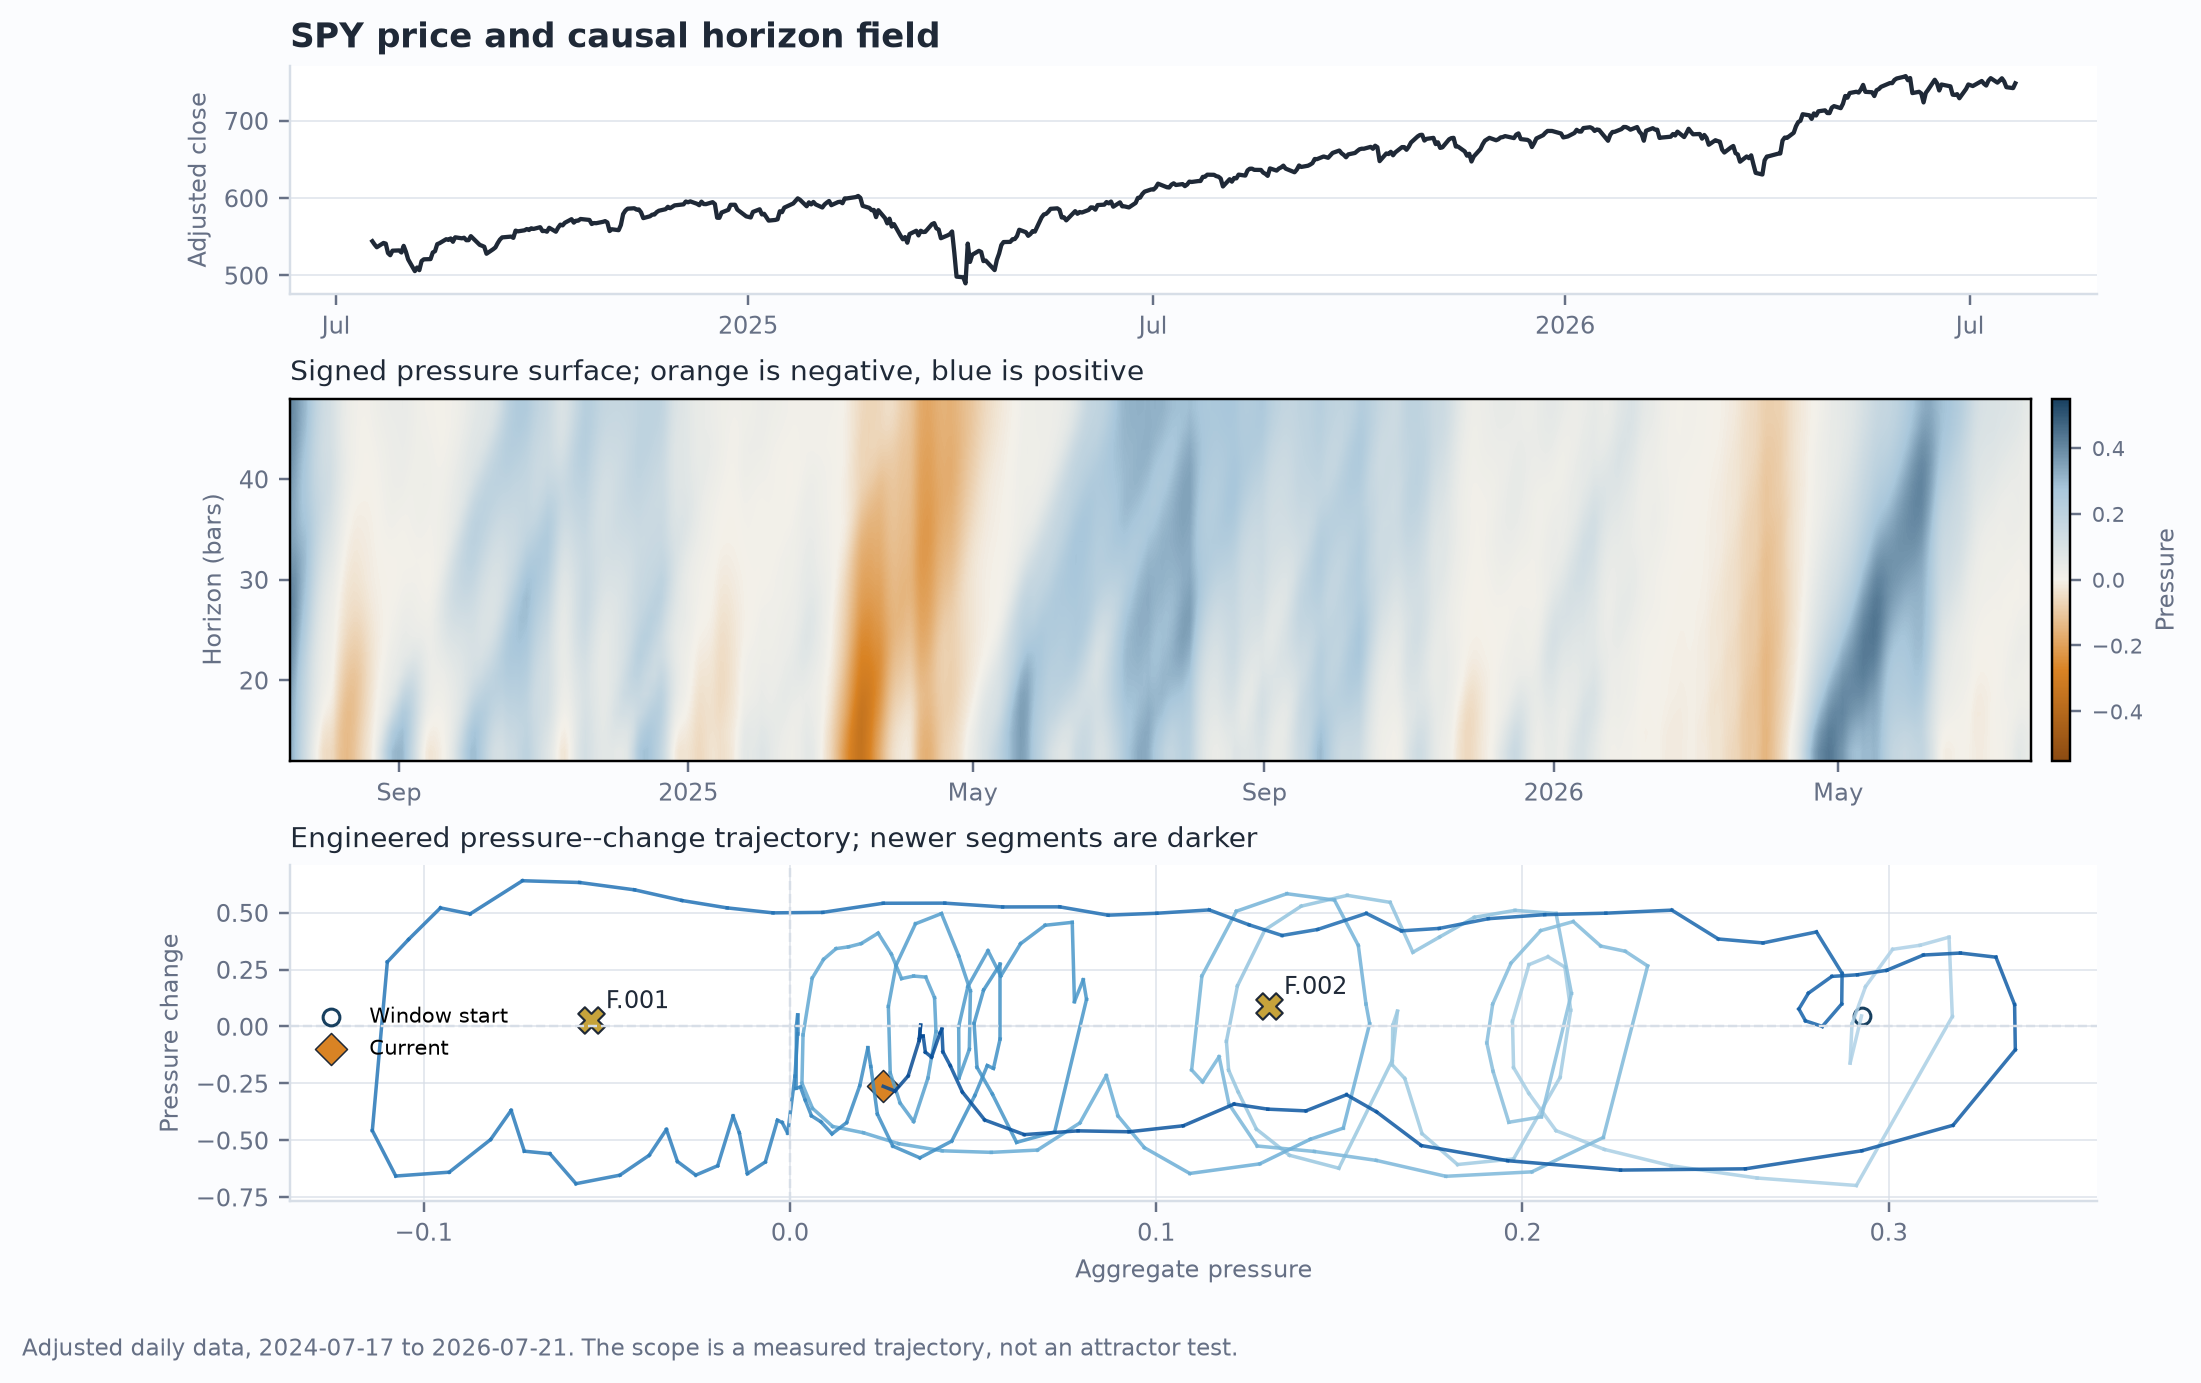

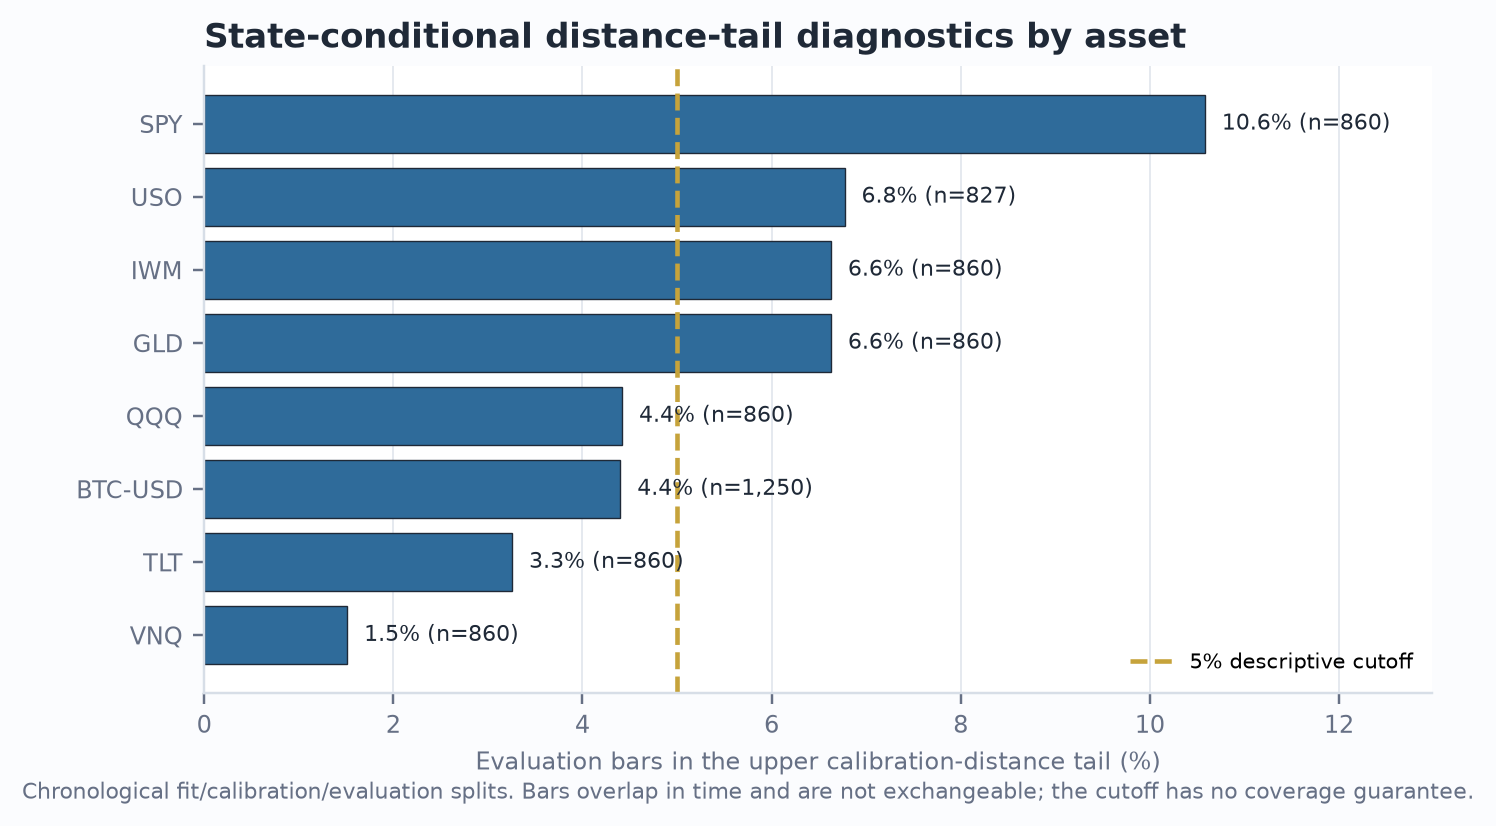

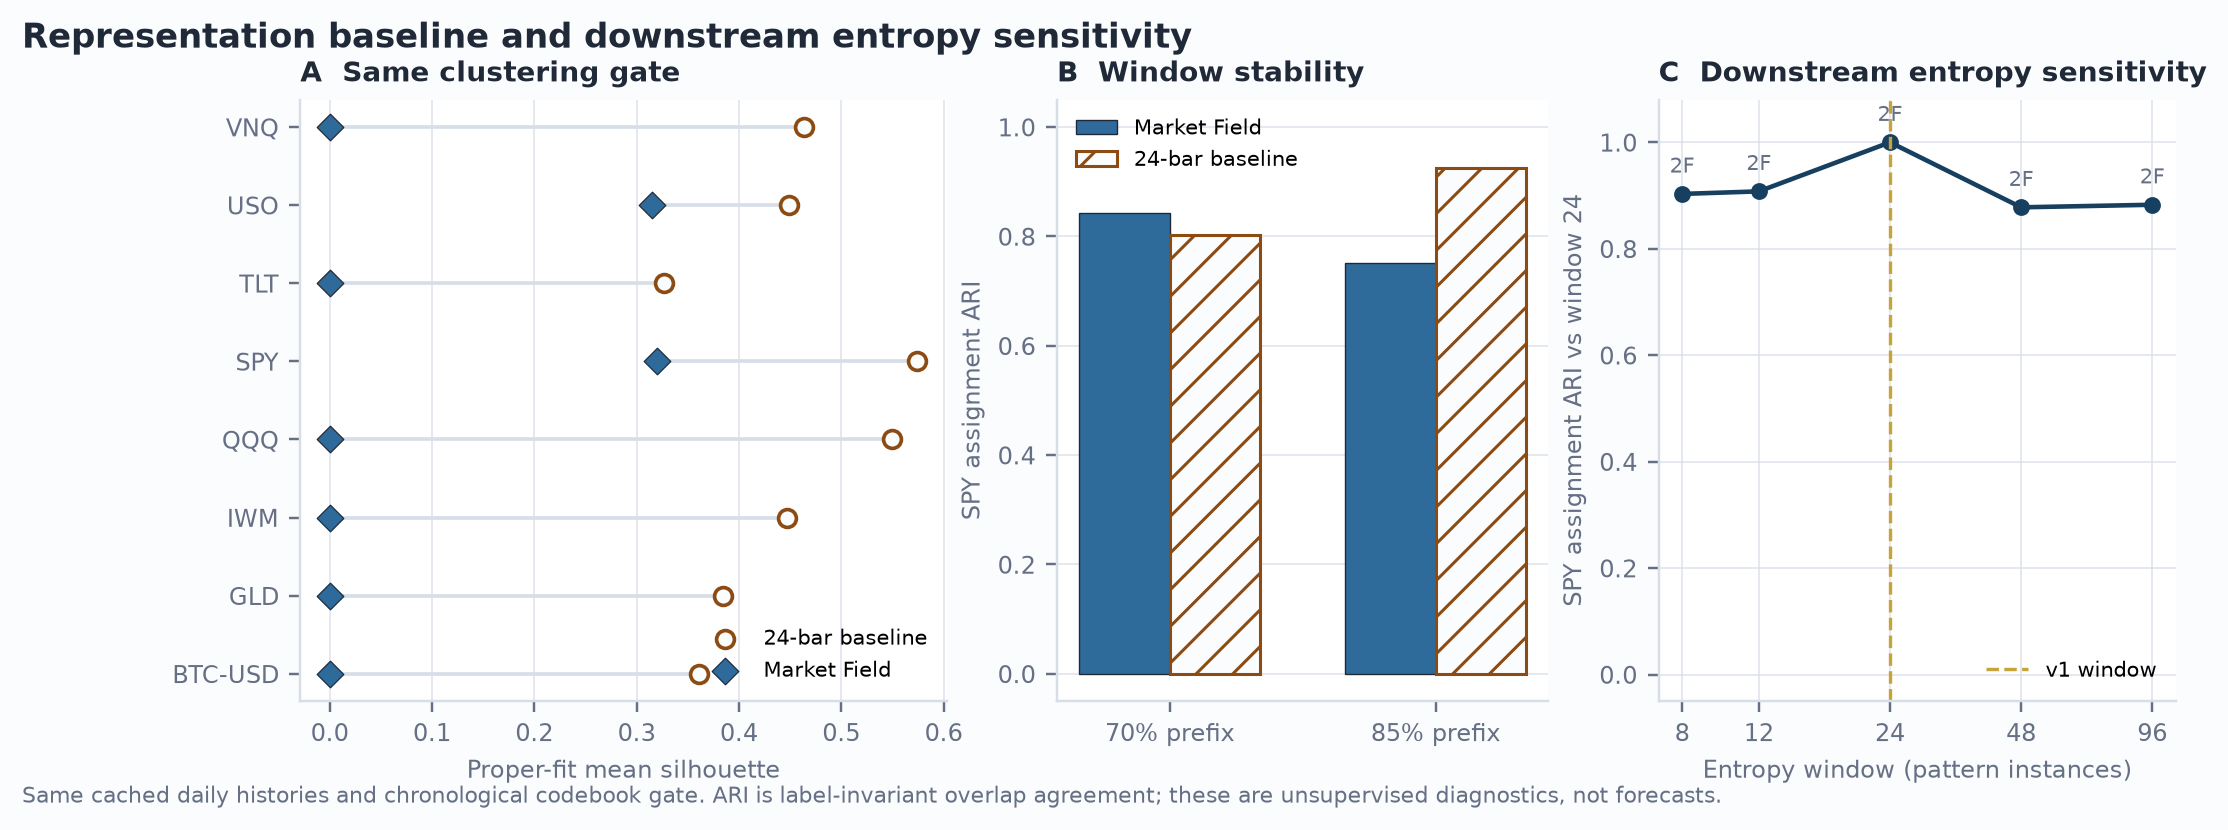

In [8]:
for filename in [
    "system_overview.png",
    "synthetic_diagnostics.png",
    "spy_field_phase.png",
    "calibration_rates.png",
    "representation_sensitivity.png",
]:
    display(Image(filename=str(PAPER_ROOT / "figures" / filename), width=1050))

## Takeaways

1. Tested serialized channels are prefix-invariant for the selected assets and
   cut points.
2. Fixed inputs produce deterministic request-local dictionaries.
3. Controlled paths generate the intended directional and scale response.
4. The cheap baseline yields 8/8 multi-Form codebooks with higher median fit
   silhouette; Market Field yields 2/8, so superior unsupervised separation is
   not supported.
5. Alternative SPY entropy windows retain two Forms and assignment ARI above
   0.87, but calibration-tail rates still vary materially.
6. Distance-tail rates are heterogeneous and must not be read as calibrated
   probabilities.
7. The option snapshot is operationally compact in a local compute-only test,
   while ranking and execution remain disabled.

Future evidence must be rolling-origin, purged, cost-aware, and prospectively
registered before any statement about option outcomes or trading value.